# 103 · Chess Siamese – copia

In [24]:
import os
import io
import json
import math
import random
import logging
import sqlite3
import itertools
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from datetime import datetime

import numpy as np
import pandas as pd
import zstandard as zstd
import chess.pgn
import cv2

import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

SEED = 314159
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use("seaborn-v0_8")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as gpu_err:
            logging.warning("No se pudo configurar memory_growth en %s: %s", gpu, gpu_err)
else:
    logging.warning("No se encontraron GPUs: se entrenar\u00e1 en CPU.")

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.17.0


In [25]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No pude localizar el directorio 'labs'.")

REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

import sys
if str(LABS_DIR / "src") not in sys.path:
    sys.path.insert(0, str(LABS_DIR / "src"))

# ── Rutas del dataset comprimido ──
PGN_DATA_DIR = Path("/pgn_data")
INDEX_DB = PGN_DATA_DIR / "index.db"
PLAYERS_DIR = PGN_DATA_DIR / "players"
assert PGN_DATA_DIR.exists(), f"Volumen de datos no montado en {PGN_DATA_DIR}"
assert INDEX_DB.exists(), f"index.db no encontrado en {INDEX_DB}"

CONFIG = {
    "event_name": "compressed_103",
    "num_blocks": 30,
    "move_range": (30, 60),
    "block_config": [(m, m, f"mv{m:02d}") for m in range(30, 60)],
    "image_size": (192, 192),
    "recon_size": (64, 64),
    "players_count": 10,
    "games_per_player": 150,
    "min_games_in_db": 300,
    "min_samples_per_player": 4,
    "validation_fraction": 0.2,
    "triplets_per_epoch": 2048,
    "val_triplets": 512,
    "batch_size": 4,
    "epochs": 2000,
    "margin": 0.1,
    "learning_rate": 1e-6,
    "embedding_cache_dir": LABS_DIR / "dataset" / "embedding_103",
    "seed": SEED,
}

OUTPUT_BASE = LABS_DIR / "notebooks" / "output" / "events" / CONFIG["event_name"]
BOARD_DIR = OUTPUT_BASE / "board_images"
HEAT_DIR = OUTPUT_BASE / "heatmap_images"
PGN_WORK_DIR = OUTPUT_BASE / "pgn_decompressed"

BLOCK_LABELS = [label for _, _, label in CONFIG["block_config"]]

print(f"Repositorio ra\u00edz: {REPO_ROOT}")
print(f"Dataset comprimido: {PGN_DATA_DIR}")
print(f"Evento: {CONFIG['event_name']}")
print(f"Bloques ({len(BLOCK_LABELS)}): {BLOCK_LABELS[:5]} ... {BLOCK_LABELS[-3:]}")

Repositorio raíz: /workspace/code
Dataset comprimido: /pgn_data
Evento: compressed_103
Bloques (30): ['mv30', 'mv31', 'mv32', 'mv33', 'mv34'] ... ['mv57', 'mv58', 'mv59']


## 1. Selección de jugadores por ELO
Consultamos `index.db` para jugadores con suficientes partidas, muestreamos candidatos
y extraemos su ELO de las cabeceras PGN. Seleccionamos 10 con ELO diverso.

In [26]:
def find_zst_path(player_name: str) -> Optional[Path]:
    """Localiza el archivo .pgn.zst de un jugador en la estructura de directorios."""
    prefix = player_name[:2].lower()
    zst_path = PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if zst_path.exists():
        return zst_path
    prefix_dir = PLAYERS_DIR / prefix
    if prefix_dir.exists():
        for f in prefix_dir.iterdir():
            if f.name.lower() == f"{player_name.lower()}.pgn.zst":
                return f
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 50_000) -> Optional[int]:
    """Extrae el ELO mediano de las primeras partidas de un archivo comprimido."""
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        elos = []
        for line in text.split("\n"):
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo_val = int(line.split('"')[1])
                    if 400 <= elo_val <= 3500:
                        elos.append(elo_val)
                except (IndexError, ValueError):
                    pass
        if elos:
            return int(np.median(elos))
    except Exception:
        pass
    return None


def select_diverse_elo_players(
    num_players: int = 10,
    min_games: int = 300,
    num_candidates: int = 200,
    seed: int = SEED,
) -> pd.DataFrame:
    """Selecciona jugadores con ELO diverso del dataset comprimido."""
    rng = random.Random(seed)

    conn = sqlite3.connect(str(INDEX_DB))
    candidates = pd.read_sql_query(
        f"SELECT name, total_games FROM players "
        f"WHERE total_games >= {min_games} ORDER BY RANDOM() LIMIT {num_candidates * 3}",
        conn,
    )
    conn.close()
    print(f"Candidatos iniciales: {len(candidates)}")

    records = []
    for _, row in candidates.iterrows():
        zst = find_zst_path(row["name"])
        if zst is None:
            continue
        elo = extract_elo_from_zst(zst)
        if elo is not None:
            records.append({
                "player": row["name"],
                "total_games": row["total_games"],
                "elo": elo,
                "zst_path": str(zst),
            })
        if len(records) >= num_candidates:
            break

    df = pd.DataFrame(records)
    print(f"Candidatos con ELO extra\u00eddo: {len(df)}")
    print(f"Rango ELO: {df['elo'].min()} \u2013 {df['elo'].max()}")

    elo_bins = list(range(600, 3000, 200))
    df["elo_bin"] = pd.cut(df["elo"], bins=elo_bins, labels=False)

    selected = []
    available_bins = sorted(df["elo_bin"].dropna().unique())
    rng.shuffle(available_bins)

    for b in available_bins:
        if len(selected) >= num_players:
            break
        bin_players = df[df["elo_bin"] == b]
        chosen = bin_players.sample(1, random_state=seed).iloc[0]
        selected.append(chosen)

    if len(selected) < num_players:
        remaining = df[~df["player"].isin([s["player"] for s in selected])]
        extra = remaining.sample(
            min(num_players - len(selected), len(remaining)),
            random_state=seed,
        )
        for _, row in extra.iterrows():
            selected.append(row)

    result = pd.DataFrame(selected).sort_values("elo").reset_index(drop=True)
    return result


selected_players_df = select_diverse_elo_players(
    num_players=CONFIG["players_count"],
    min_games=CONFIG["min_games_in_db"],
    seed=CONFIG["seed"],
)
SELECTED_PLAYERS = selected_players_df["player"].tolist()
PLAYER_ELO = dict(zip(selected_players_df["player"], selected_players_df["elo"]))

display(selected_players_df[["player", "elo", "total_games"]])
print(f"\nJugadores seleccionados: {len(SELECTED_PLAYERS)}")
print(f"Rango ELO: {selected_players_df['elo'].min()} \u2013 {selected_players_df['elo'].max()}")

Candidatos iniciales: 600
Candidatos con ELO extraído: 200
Rango ELO: 728 – 2346


,player,elo,total_games
0,daniilprotopopov,747,427
1,JhoanR,871,506
2,Liquidador2013,945,709
3,JMarcSennechael,1174,928
4,paulheetik,1311,301
5,vvjsingh,1597,382
6,KASIKE-ULTRA,1763,1115
7,ekongson,1831,805
8,IJsvogel,2130,657
9,borets77,2346,989



Jugadores seleccionados: 10
Rango ELO: 747 – 2346


## 2. Descompresión de PGNs

Descomprime los archivos `.pgn.zst` de los jugadores seleccionados y limita
a `games_per_player` partidas cada uno.

In [27]:
def decompress_player_pgn(
    player_name: str,
    zst_path: str,
    output_dir: Path,
    max_games: int = 150,
) -> Tuple[Path, int]:
    """Descomprime PGN y limita a max_games partidas."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{player_name}.pgn"

    dctx = zstd.ZstdDecompressor()
    with open(zst_path, "rb") as f:
        reader = dctx.stream_reader(f)
        full_text = reader.read().decode("utf-8", errors="replace")

    games_written = 0
    lines = full_text.split("\n")
    output_lines = []
    in_game = False

    for line in lines:
        if line.startswith("[Event "):
            if in_game:
                games_written += 1
                if games_written >= max_games:
                    break
            in_game = True
        output_lines.append(line)

    if in_game and games_written < max_games:
        games_written += 1

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n".join(output_lines))

    return output_path, games_written


PGN_WORK_DIR.mkdir(parents=True, exist_ok=True)
decompression_results = []

for _, row in selected_players_df.iterrows():
    pgn_path, num_games = decompress_player_pgn(
        row["player"],
        row["zst_path"],
        PGN_WORK_DIR,
        max_games=CONFIG["games_per_player"],
    )
    decompression_results.append({
        "player": row["player"],
        "elo": row["elo"],
        "pgn_path": str(pgn_path),
        "games_extracted": num_games,
    })
    print(f"  {row['player']} (ELO {row['elo']}): {num_games} partidas")

decompression_df = pd.DataFrame(decompression_results)
print(f"\nTotal partidas descomprimidas: {decompression_df['games_extracted'].sum()}")

  daniilprotopopov (ELO 747): 150 partidas
  JhoanR (ELO 871): 150 partidas
  Liquidador2013 (ELO 945): 150 partidas
  JMarcSennechael (ELO 1174): 150 partidas
  paulheetik (ELO 1311): 150 partidas
  vvjsingh (ELO 1597): 150 partidas
  KASIKE-ULTRA (ELO 1763): 150 partidas
  ekongson (ELO 1831): 150 partidas
  IJsvogel (ELO 2130): 150 partidas
  borets77 (ELO 2346): 150 partidas

Total partidas descomprimidas: 1500


## 3. Generación de imágenes per-move (board + heatmap)

Generamos por partida 30 instantaneas del tablero y otras 30 del heatmap

In [28]:
from parse_games_to_images import board_to_png_array
from generate_decision_heatmaps import DecisionTimeExtractor

OUTPUT_SIZE = CONFIG["image_size"][0]  # 192
START_HM, END_HM = CONFIG["move_range"]  # (30, 60)
MOVE_LABELS = [f"mv{m:02d}" for m in range(START_HM, END_HM)]


def generate_per_move_images(
    pgn_path: Path,
    output_board: Path,
    output_heat: Path,
    start_hm: int = START_HM,
    end_hm: int = END_HM,
    verbose: bool = True,
) -> Dict:
    """Genera 1 imagen de tablero + 1 heatmap por cada halfmove en [start_hm, end_hm)."""
    output_board.mkdir(parents=True, exist_ok=True)
    output_heat.mkdir(parents=True, exist_ok=True)
    extractor = DecisionTimeExtractor()
    n_moves = end_hm - start_hm

    stats = {"games_processed": 0, "games_skipped": 0,
             "boards_created": 0, "heatmaps_created": 0, "errors": 0}

    with open(pgn_path) as pgn_file:
        game_num = 0
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            game_num += 1

            try:
                moves = list(game.mainline_moves())
                if len(moves) < end_hm:
                    stats["games_skipped"] += 1
                    continue

                decisions = extractor.extract_decision_times(game, use_relative=True)
                decision_map = {d.move_number: d for d in decisions}

                board = game.board()
                board_states = {}
                for idx, move in enumerate(moves):
                    hm = idx + 1
                    board.push(move)
                    if start_hm <= hm < end_hm:
                        board_states[hm] = board.copy()
                    if hm >= end_hm:
                        break

                if len(board_states) < n_moves:
                    stats["games_skipped"] += 1
                    continue

                for hm in range(start_hm, end_hm):
                    label = f"mv{hm:02d}"

                    board_img = board_to_png_array(board_states[hm], size=400)
                    board_resized = cv2.resize(
                        board_img, (OUTPUT_SIZE, OUTPUT_SIZE),
                        interpolation=cv2.INTER_AREA,
                    )
                    cv2.imwrite(
                        str(output_board / f"game_{game_num:04d}_{label}.png"),
                        board_resized,
                    )

                    grid = np.zeros((8, 8), dtype=np.uint8)
                    move_obj = moves[hm - 1]
                    from_sq = move_obj.from_square
                    to_sq = move_obj.to_square
                    fr, fc = 7 - from_sq // 8, from_sq % 8
                    tr, tc = 7 - to_sq // 8, to_sq % 8

                    if hm in decision_map:
                        pct = decision_map[hm].decision_pct
                        brightness = int(np.clip(30 + pct * 45, 30, 255))
                    else:
                        brightness = 60

                    grid[fr, fc] = brightness
                    grid[tr, tc] = max(30, brightness // 2)

                    heat_bgr = cv2.cvtColor(grid, cv2.COLOR_GRAY2BGR)
                    heat_resized = cv2.resize(
                        heat_bgr, (OUTPUT_SIZE, OUTPUT_SIZE),
                        interpolation=cv2.INTER_NEAREST,
                    )
                    cv2.imwrite(
                        str(output_heat / f"game_{game_num:04d}_{label}.png"),
                        heat_resized,
                    )

                stats["games_processed"] += 1
                stats["boards_created"] += n_moves
                stats["heatmaps_created"] += n_moves

            except Exception as e:
                stats["errors"] += 1
                for hm in range(start_hm, end_hm):
                    for d in [output_board, output_heat]:
                        fp = d / f"game_{game_num:04d}_mv{hm:02d}.png"
                        if fp.exists():
                            fp.unlink()
                if verbose:
                    print(f"  Game {game_num} error: {e}")
                continue

            if verbose and game_num % 25 == 0:
                print(f"  Procesadas: {game_num} | "
                      f"V\u00e1lidas: {stats['games_processed']} | "
                      f"Saltadas: {stats['games_skipped']}")

    if verbose:
        print(f"  Completado: {stats['games_processed']} partidas, "
              f"{stats['boards_created']} tableros, "
              f"{stats['heatmaps_created']} heatmaps")
    return stats


BOARD_DIR.mkdir(parents=True, exist_ok=True)
HEAT_DIR.mkdir(parents=True, exist_ok=True)

image_stats = []
for _, row in decompression_df.iterrows():
    player = row["player"]
    pgn_path = Path(row["pgn_path"])

    print(f"\n{'\u2500' * 60}")
    print(f"Procesando: {player} (ELO {row['elo']})")

    stats = generate_per_move_images(
        pgn_path=pgn_path,
        output_board=BOARD_DIR / player,
        output_heat=HEAT_DIR / player,
    )
    stats["player"] = player
    image_stats.append(stats)

stats_df = pd.DataFrame(image_stats)
display(stats_df[["player", "games_processed", "boards_created",
                  "heatmaps_created", "games_skipped"]])

print(f"\nTotal tableros: {stats_df['boards_created'].sum()}")
print(f"Total heatmaps: {stats_df['heatmaps_created'].sum()}")


────────────────────────────────────────────────────────────
Procesando: daniilprotopopov (ELO 747)
  Procesadas: 25 | Válidas: 25 | Saltadas: 0
  Procesadas: 50 | Válidas: 50 | Saltadas: 0
  Procesadas: 75 | Válidas: 75 | Saltadas: 0
  Procesadas: 100 | Válidas: 100 | Saltadas: 0
  Procesadas: 125 | Válidas: 125 | Saltadas: 0
  Procesadas: 150 | Válidas: 150 | Saltadas: 0
  Completado: 150 partidas, 4500 tableros, 4500 heatmaps

────────────────────────────────────────────────────────────
Procesando: JhoanR (ELO 871)
  Procesadas: 25 | Válidas: 25 | Saltadas: 0
  Procesadas: 50 | Válidas: 50 | Saltadas: 0
  Procesadas: 75 | Válidas: 75 | Saltadas: 0
  Procesadas: 100 | Válidas: 100 | Saltadas: 0
  Procesadas: 125 | Válidas: 125 | Saltadas: 0
  Procesadas: 150 | Válidas: 150 | Saltadas: 0
  Completado: 150 partidas, 4500 tableros, 4500 heatmaps

────────────────────────────────────────────────────────────
Procesando: Liquidador2013 (ELO 945)
  Procesadas: 25 | Válidas: 25 | Saltadas: 

,player,games_processed,boards_created,heatmaps_created,games_skipped
0,daniilprotopopov,150,4500,4500,0
1,JhoanR,150,4500,4500,0
2,Liquidador2013,150,4500,4500,0
3,JMarcSennechael,150,4500,4500,0
4,paulheetik,150,4500,4500,0
5,vvjsingh,150,4500,4500,0
6,KASIKE-ULTRA,150,4500,4500,0
7,ekongson,150,4500,4500,0
8,IJsvogel,150,4500,4500,0
9,borets77,150,4500,4500,0



Total tableros: 45000
Total heatmaps: 45000


## 4. Descubrimiento de muestras y split train/val

In [29]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]
    event: str


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    block_labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
    max_games_per_player: Optional[int] = None,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist_set = (
        {name.replace(" ", "_") for name in players_whitelist}
        if players_whitelist else None
    )
    samples_by_player: Dict[str, List[GameSample]] = {}
    if not board_dir.exists():
        raise RuntimeError(f"BOARD_DIR no existe: {board_dir}\n"
                           "Ejecuta primero la celda de generaci\u00f3n de im\u00e1genes.")
    player_dirs = sorted([d for d in board_dir.iterdir() if d.is_dir()])
    first_block = block_labels[0]

    for player_dir in player_dirs:
        player_name = player_dir.name
        if whitelist_set and player_name not in whitelist_set:
            continue

        heat_player_dir = heat_dir / player_name
        if not heat_player_dir.exists():
            continue

        game_ids = sorted({
            path.stem.split("_")[1]
            for path in player_dir.glob(f"game_*_{first_block}.png")
        })
        if not game_ids:
            continue

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths, heat_paths = [], []
            valid = True
            for block_label in block_labels:
                bp = player_dir / f"game_{game_id}_{block_label}.png"
                hp = heat_player_dir / f"game_{game_id}_{block_label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue
            player_samples.append(GameSample(
                player=player_name,
                game_id=game_id,
                board_paths=tuple(board_paths),
                heat_paths=tuple(heat_paths),
                event=CONFIG["event_name"],
            ))
            if max_games_per_player and len(player_samples) >= max_games_per_player:
                break

        if len(player_samples) >= min_samples:
            samples_by_player[player_name] = player_samples

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    if not rows:
        raise RuntimeError(
            f"No se encontraron muestras. Comprueba BOARD_DIR={board_dir}"
        )
    stats_df = pd.DataFrame(rows).sort_values("games", ascending=False).reset_index(drop=True)
    return samples_by_player, stats_df


def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[Dict[str, List[GameSample]], Dict[str, List[GameSample]],
           List[GameSample], List[GameSample]]:
    rng = random.Random(seed)
    train_dict, val_dict = {}, {}

    for player, samples in samples_by_player.items():
        copies = samples.copy()
        rng.shuffle(copies)
        val_count = max(1, int(len(copies) * val_fraction))
        while val_count > 0 and len(copies) - val_count < 2:
            val_count -= 1
        val_samples = copies[:val_count] if val_count > 0 else []
        train_samples = copies[val_count:]
        if len(train_samples) < 2:
            continue
        train_dict[player] = train_samples
        val_dict[player] = val_samples

    train_flat = [s for ss in train_dict.values() for s in ss]
    val_flat = [s for ss in val_dict.values() for s in ss]
    return train_dict, val_dict, train_flat, val_flat


samples_by_player, player_stats = discover_game_samples(
    BOARD_DIR, HEAT_DIR, BLOCK_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG["min_samples_per_player"],
)
display(player_stats)

total_players = len(samples_by_player)
total_games = sum(len(s) for s in samples_by_player.values())
print(f"Jugadores v\u00e1lidos: {total_players}")
print(f"Partidas disponibles: {total_games}")

train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player, CONFIG["validation_fraction"], CONFIG["seed"],
)
print(f"Muestras entrenamiento: {len(TRAIN_SAMPLES)}")
print(f"Muestras validaci\u00f3n: {len(VAL_SAMPLES)}")

pd.DataFrame({
    "player": list(train_by_player.keys()),
    "train": [len(v) for v in train_by_player.values()],
    "val": [len(val_by_player.get(p, [])) for p in train_by_player],
    "elo": [PLAYER_ELO.get(p, "?") for p in train_by_player],
}).sort_values("elo").reset_index(drop=True)

,player,games
0,IJsvogel,150
1,JMarcSennechael,150
2,JhoanR,150
3,KASIKE-ULTRA,150
4,Liquidador2013,150
5,borets77,150
6,daniilprotopopov,150
7,ekongson,150
8,paulheetik,150
9,vvjsingh,150


Jugadores válidos: 10
Partidas disponibles: 1500
Muestras entrenamiento: 1200
Muestras validación: 300


,player,train,val,elo
0,daniilprotopopov,120,30,747
1,JhoanR,120,30,871
2,Liquidador2013,120,30,945
3,JMarcSennechael,120,30,1174
4,paulheetik,120,30,1311
5,vvjsingh,120,30,1597
6,KASIKE-ULTRA,120,30,1763
7,ekongson,120,30,1831
8,IJsvogel,120,30,2130
9,borets77,120,30,2346


## 5. Tripletes dinámicos y Dataset TF


In [30]:
IMG_HEIGHT, IMG_WIDTH = CONFIG["image_size"]
NUM_BLOCKS = CONFIG["num_blocks"]


class TripletFactory:
    def __init__(self, samples_by_player: Dict[str, List[GameSample]]):
        self.samples_by_player = {
            player: tuple(samples)
            for player, samples in samples_by_player.items()
            if len(samples) >= 2
        }
        self.players = sorted(self.samples_by_player.keys())
        if len(self.players) < 2:
            raise ValueError("Se requieren >=2 jugadores con >=2 partidas.")

    def build(self, num_triplets: int, seed: int) -> List[Tuple[GameSample, GameSample, GameSample]]:
        rng = random.Random(seed)
        triplets = []
        max_attempts = max(num_triplets * 20, 1000)
        attempts = 0

        while len(triplets) < num_triplets and attempts < max_attempts:
            attempts += 1
            anchor_player = rng.choice(self.players)
            positives = self.samples_by_player[anchor_player]
            if len(positives) < 2:
                continue
            anchor_sample, positive_sample = rng.sample(positives, 2)

            negative_candidates = [p for p in self.players if p != anchor_player]
            if not negative_candidates:
                continue
            negative_player = rng.choice(negative_candidates)
            negative_sample = rng.choice(self.samples_by_player[negative_player])
            triplets.append((anchor_sample, positive_sample, negative_sample))

        if len(triplets) < num_triplets:
            logging.warning("Solo %d/%d tripletes.", len(triplets), num_triplets)
        return triplets
    def build_semihard(
        self,
        num_triplets: int,
        seed: int,
        embedding_model,
        samples_flat: List[GameSample],
        batch_size: int,
        margin: float,
        max_probe: int = 300,
    ) -> List[Tuple[GameSample, GameSample, GameSample]]:
        """Mine semi-hard negatives: d(a,p) < d(a,n) < d(a,p) + margin.

        Computes embeddings over a random probe subset (max_probe samples) to
        avoid a full forward pass over the entire training set each epoch.
        Falls back to random triplets when not enough semi-hard found.
        """
        rng = random.Random(seed)
        probe = rng.sample(samples_flat, min(max_probe, len(samples_flat)))

        # Embeddings for the probe subset
        board_probe = np.array([s.board_paths for s in probe])
        heat_probe  = np.array([s.heat_paths  for s in probe])
        ds_probe = tf.data.Dataset.from_tensor_slices(
            {"board": board_probe, "heat": heat_probe}
        )
        ds_probe = ds_probe.map(
            lambda s: load_sample(s["board"], s["heat"]), num_parallel_calls=2
        )
        ds_probe = ds_probe.batch(batch_size).prefetch(2)
        ds_probe = ds_probe.map(lambda b, h: {"board_sequence": b, "heat_sequence": h})
        probe_embs = embedding_model.predict(ds_probe, verbose=0)  # (n_probe, 256)

        # Index probe samples by player
        player_to_probe: Dict[str, List[int]] = {}
        for i, s in enumerate(probe):
            player_to_probe.setdefault(s.player, []).append(i)
        valid_players = [p for p, idxs in player_to_probe.items() if len(idxs) >= 2]

        triplets: List[Tuple[GameSample, GameSample, GameSample]] = []
        fallback: List[Tuple[GameSample, GameSample, GameSample]] = []
        max_attempts = max(num_triplets * 30, 3000)
        attempts = 0

        while attempts < max_attempts and len(triplets) < num_triplets:
            attempts += 1
            if not valid_players:
                break
            anchor_player = rng.choice(valid_players)
            ai, pi = rng.sample(player_to_probe[anchor_player], 2)

            other_players = [p for p in valid_players if p != anchor_player]
            if not other_players:
                continue
            neg_player = rng.choice(other_players)
            ni = rng.choice(player_to_probe[neg_player])

            d_ap = float(np.linalg.norm(probe_embs[ai] - probe_embs[pi]))
            d_an = float(np.linalg.norm(probe_embs[ai] - probe_embs[ni]))

            t = (probe[ai], probe[pi], probe[ni])
            if d_ap < d_an < d_ap + margin:
                triplets.append(t)
            else:
                fallback.append(t)

        # Supplement with random fallback when not enough semi-hard found
        if len(triplets) < num_triplets:
            rng.shuffle(fallback)
            triplets.extend(fallback[: num_triplets - len(triplets)])
        if len(triplets) < num_triplets:
            extra = self.build(num_triplets - len(triplets), seed + 999)
            triplets.extend(extra)
            logging.warning(
                "Semi-hard mining: solo %d/%d tripletes semi-hard. Resto aleatorio.",
                num_triplets - len(extra), num_triplets,
            )

        return triplets[:num_triplets]




def _decode_board(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return tf.image.convert_image_dtype(image, tf.float32)


def _decode_heat(path: tf.Tensor) -> tf.Tensor:
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return tf.image.convert_image_dtype(image, tf.float32)


def load_sample(board_paths: tf.Tensor, heat_paths: tf.Tensor):
    board = tf.map_fn(
        _decode_board, board_paths,
        fn_output_signature=tf.TensorSpec(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32
        ),
        parallel_iterations=4,
    )
    heat = tf.map_fn(
        _decode_heat, heat_paths,
        fn_output_signature=tf.TensorSpec(
            shape=(IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.float32
        ),
        parallel_iterations=4,
    )
    return board, heat


def _decode_board_small(path: tf.Tensor) -> tf.Tensor:
    """Decodifica imagen board a tama\u00f1o reducido para reconstrucci\u00f3n."""
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=3)
    image = tf.image.resize(image, CONFIG["recon_size"])
    return image/255.0 # Retornamos el valor de la imagen normalizada 


def serialize_triplets(triplets):
    arrays = {
        "anchor_board": [], "anchor_heat": [],
        "positive_board": [], "positive_heat": [],
        "negative_board": [], "negative_heat": [],
    }
    for anchor, positive, negative in triplets:
        arrays["anchor_board"].append(anchor.board_paths)
        arrays["anchor_heat"].append(anchor.heat_paths)
        arrays["positive_board"].append(positive.board_paths)
        arrays["positive_heat"].append(positive.heat_paths)
        arrays["negative_board"].append(negative.board_paths)
        arrays["negative_heat"].append(negative.heat_paths)
    return {k: np.array(v) for k, v in arrays.items()}


def build_tf_dataset(triplet_dict, batch_size, shuffle, description):
    """Construye dataset TF con imagen de reconstrucci\u00f3n incluida."""
    ds = tf.data.Dataset.from_tensor_slices(triplet_dict)
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(triplet_dict["anchor_board"]),
            seed=CONFIG["seed"],
            reshuffle_each_iteration=True,
        )

    def mapper(sample):
        ab, ah = load_sample(sample["anchor_board"], sample["anchor_heat"])
        pb, ph = load_sample(sample["positive_board"], sample["positive_heat"])
        nb, nh = load_sample(sample["negative_board"], sample["negative_heat"])
        return {
            "anchor_board": ab, "anchor_heat": ah,
            "positive_board": pb, "positive_heat": ph,
            "negative_board": nb, "negative_heat": nh,
        }, tf.zeros((1,), dtype=tf.float32)

    ds = ds.map(mapper, num_parallel_calls=2)
    ds = ds.batch(batch_size).prefetch(2)

    n = len(triplet_dict["anchor_board"])
    print(f"{description}: {n} tripletes (~{max(1, math.ceil(n / batch_size))} batches)")
    return ds


triplet_factory = TripletFactory(train_by_player)
val_triplet_factory = TripletFactory(val_by_player)

# Generar tripletes iniciales (se regenerarán cada epoch)
train_triplets = triplet_factory.build(CONFIG["triplets_per_epoch"], CONFIG["seed"])
val_triplets = val_triplet_factory.build(CONFIG["val_triplets"], CONFIG["seed"] + 41)

train_dataset = build_tf_dataset(
    serialize_triplets(train_triplets), CONFIG["batch_size"],
    shuffle=True, description="Train",
)
val_dataset = build_tf_dataset(
    serialize_triplets(val_triplets), CONFIG["batch_size"],
    shuffle=False, description="Val",
)

Train: 2048 tripletes (~512 batches)
Val: 512 tripletes (~128 batches)


## 6. Modelo: Encoder + Red Siamesa

### Encoder (capas congeladas y entrenables):
- **ResNet50** (CONGELADA): extractor de features visuales pre-entrenado
- Dense(512, gelu) + Dropout(0.2): proyección trainable sobre features de ResNet50
- heat_encoder CNN: Conv2D(32) → MaxPool → Conv2D(64) → GlobalAvgPool → Dense(256)
- Fusión: Concatenar [512+256=768] → LayerNorm → Dense(256)
- Temporal: Masking → Bidirectional GRU(256) → GlobalAvgPool
- Head: Dense(512) → Dropout(0.3) → Dense(256) → L2 normalize → **embedding 256D**

### Decoder (sección 7b, entrenado por separado):
- embedding 256D → Dense(8×8×64) → Reshape → ConvTranspose × 3 → imagen 64×64×3
- Target: media temporal de los 30 frames del tablero (ver sección 7b)

In [31]:
def build_embedding_model(num_blocks: int, img_shape: Tuple[int, int]) -> Model:
    board_input = layers.Input(
        shape=(num_blocks, img_shape[0], img_shape[1], 3), name="board_sequence"
    )
    heat_input = layers.Input(
        shape=(num_blocks, img_shape[0], img_shape[1], 1), name="heat_sequence"
    )

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet",
        input_shape=(img_shape[0], img_shape[1], 3),
    )
    base_cnn.trainable = False

    board_encoder = tf.keras.Sequential([
        base_cnn,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="gelu"),
        layers.Dropout(0.2),
    ], name="board_encoder")

    heat_encoder = tf.keras.Sequential([
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="gelu"),
    ], name="heat_encoder")

    board_features = layers.TimeDistributed(board_encoder, name="board_td")(board_input)
    heat_features = layers.TimeDistributed(heat_encoder, name="heat_td")(heat_input)

    fused = layers.Concatenate(name="block_fusion")([board_features, heat_features])
    fused = layers.LayerNormalization()(fused)
    fused = layers.TimeDistributed(
        layers.Dense(256, activation="gelu"), name="block_dense"
    )(fused)

    masked_sequence = layers.Masking(mask_value=0.0, name="temporal_mask")(fused)
    temporal = layers.Bidirectional(
        layers.GRU(256, return_sequences=True), name="temporal_encoder",
    )(masked_sequence)
    pooled = layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    dense = layers.Dense(512, activation="gelu")(pooled)
    dense = layers.Dropout(0.3)(dense)
    dense = layers.Dense(256, activation="gelu")(dense)
    normalized = layers.Lambda(
        lambda x: tf.math.l2_normalize(x, axis=1), name="l2_norm"
    )(dense)

    return Model(
        inputs=[board_input, heat_input],
        outputs=normalized,
        name="stylometry_embedding",
    )


def build_decoder(embedding_dim: int = 256, output_shape: Tuple[int, int] = (64, 64)) -> Model:
    """Decoder: embedding 256D \u2192 imagen reconstruida 64\u00d764\u00d73."""
    emb_input = layers.Input(shape=(embedding_dim,), name="embedding_input")

    x = layers.Dense(8 * 8 * 64, activation="gelu")(emb_input)
    x = layers.Reshape((8, 8, 64))(x)

    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)  # 16x16
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)  # 32x32
    x = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(x)  # 64x64
    x = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="recon_output")(x)  # 64x64x3

    return Model(inputs=emb_input, outputs=x, name="image_decoder")


class DistanceLayer(layers.Layer):
    """Distancia euclidiana L2."""

    def call(self, anchor, positive, negative):
        ap_distance = tf.sqrt(
            tf.reduce_sum(tf.square(anchor - positive), axis=1) + 1e-8
        )
        an_distance = tf.sqrt(
            tf.reduce_sum(tf.square(anchor - negative), axis=1) + 1e-8
        )
        return ap_distance, an_distance


class SiameseModel(Model):
    def __init__(self, siamese_network: Model, margin: float = 0.1):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def _compute_loss(self, data, training=True):
        features, _ = data
        siamese_inputs = {k: features[k] for k in [
            "anchor_board", "anchor_heat",
            "positive_board", "positive_heat",
            "negative_board", "negative_heat",
        ]}
        ap_dist, an_dist = self.siamese_network(siamese_inputs, training=training)
        return tf.reduce_mean(tf.maximum(ap_dist - an_dist + self.margin, 0.0))

    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data, training=True)
        grads = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.siamese_network.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data, training=False)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker]

## 7. Entrenamiento

Loss: **triplet loss** con margen `CONFIG["margin"]`.
Tripletes dinámicos regenerados cada epoch.
Primeras `WARMUP_EPOCHS` epochs con tripletes aleatorios; después semi-hard mining.

In [32]:
embedding_model = build_embedding_model(CONFIG["num_blocks"], CONFIG["image_size"])


def build_branch(prefix: str):
    board_in = layers.Input(
        shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 3),
        name=f"{prefix}_board",
    )
    heat_in = layers.Input(
        shape=(CONFIG["num_blocks"], IMG_HEIGHT, IMG_WIDTH, 1),
        name=f"{prefix}_heat",
    )
    emb = embedding_model([board_in, heat_in])
    return board_in, heat_in, emb


anchor_board_in,   anchor_heat_in,   anchor_emb   = build_branch("anchor")
positive_board_in, positive_heat_in, positive_emb = build_branch("positive")
negative_board_in, negative_heat_in, negative_emb = build_branch("negative")

distance_layer = DistanceLayer(name="distance")
ap_dist, an_dist = distance_layer(anchor_emb, positive_emb, negative_emb)

siamese_network = Model(
    inputs=[
        anchor_board_in, anchor_heat_in,
        positive_board_in, positive_heat_in,
        negative_board_in, negative_heat_in,
    ],
    outputs=(ap_dist, an_dist),
    name="siamese_network",
)
siamese_network.summary(line_length=140)

siamese_model = SiameseModel(siamese_network, margin=CONFIG["margin"])
siamese_model.compile(optimizer=tf.keras.optimizers.Adam(CONFIG["learning_rate"]))


class DistanceTracker(tf.keras.callbacks.Callback):
    def __init__(self, val_samples, emb_model, every_n=5, max_pairs=200):
        super().__init__()
        self.val_samples = val_samples
        self.emb_model = emb_model
        self.every_n = every_n
        self.max_pairs = max_pairs
        self.history = {"epoch": [], "mean_intra": [], "mean_inter": [], "gap": []}

    def _compute_distances(self):
        board_paths = np.array([s.board_paths for s in self.val_samples])
        heat_paths  = np.array([s.heat_paths  for s in self.val_samples])
        ds = tf.data.Dataset.from_tensor_slices({"board": board_paths, "heat": heat_paths})
        ds = ds.map(lambda s: load_sample(s["board"], s["heat"]), num_parallel_calls=2)
        ds = ds.batch(CONFIG["batch_size"]).prefetch(2)
        ds = ds.map(lambda b, h: {"board_sequence": b, "heat_sequence": h})
        embs = self.emb_model.predict(ds, verbose=0)
        players = [s.player for s in self.val_samples]
        intra, inter = [], []
        rng = random.Random(42)
        pairs = list(itertools.combinations(range(len(embs)), 2))
        if len(pairs) > self.max_pairs:
            pairs = rng.sample(pairs, self.max_pairs)
        for i, j in pairs:
            d = float(np.linalg.norm(embs[i] - embs[j]))
            (intra if players[i] == players[j] else inter).append(d)
        return (
            float(np.mean(intra)) if intra else 0.0,
            float(np.mean(inter)) if inter else 0.0,
        )

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0 or epoch == 0:
            m_intra, m_inter = self._compute_distances()
            gap = m_inter - m_intra
            self.history["epoch"].append(epoch + 1)
            self.history["mean_intra"].append(m_intra)
            self.history["mean_inter"].append(m_inter)
            self.history["gap"].append(gap)
            print(f"  [DistTracker] ep {epoch + 1}: intra={m_intra:.4f}  "
                  f"inter={m_inter:.4f}  gap={gap:.4f}")


distance_tracker = DistanceTracker(VAL_SAMPLES, embedding_model, every_n=5, max_pairs=300)


# ── Loop de entrenamiento con tripletes dinámicos ─────────────────────────────
WARMUP_EPOCHS = 10

es_patience = 50
lr_patience = 25
lr_factor   = 0.5
min_lr      = 1e-7

best_val_loss = float("inf")
es_counter    = 0
lr_counter    = 0
current_lr    = CONFIG["learning_rate"]
best_weights  = None
all_history: Dict[str, list] = {"loss": [], "val_loss": []}

for epoch in range(CONFIG["epochs"]):
    seed = CONFIG["seed"] + epoch * 7919

    if epoch < WARMUP_EPOCHS:
        new_train = triplet_factory.build(CONFIG["triplets_per_epoch"], seed)
    else:
        new_train = triplet_factory.build_semihard(
            CONFIG["triplets_per_epoch"], seed,
            embedding_model, TRAIN_SAMPLES,
            CONFIG["batch_size"], CONFIG["margin"],
        )
    new_val  = val_triplet_factory.build(CONFIG["val_triplets"], seed + 31)
    train_ds = build_tf_dataset(
        serialize_triplets(new_train), CONFIG["batch_size"],
        shuffle=True, description=f"Train (ep {epoch + 1})",
    )
    val_ds = build_tf_dataset(
        serialize_triplets(new_val), CONFIG["batch_size"],
        shuffle=False, description=f"Val (ep {epoch + 1})",
    )

    hist = siamese_model.fit(train_ds, validation_data=val_ds, epochs=1, verbose=1)

    for k in ["loss", "val_loss"]:
        if k in hist.history:
            all_history[k].extend(hist.history[k])

    val_loss = hist.history["val_loss"][0]
    distance_tracker.on_epoch_end(epoch)

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        es_counter    = 0
        lr_counter    = 0
        best_weights  = siamese_model.get_weights()
        print(f"  [EarlyStopping] ✓ Mejor val_loss={best_val_loss:.6f}")
    else:
        es_counter += 1
        lr_counter += 1
        if lr_counter >= lr_patience:
            new_lr = max(current_lr * lr_factor, min_lr)
            if new_lr < current_lr:
                current_lr = new_lr
                siamese_model.optimizer.learning_rate.assign(current_lr)
                print(f"  [ReduceLR] lr → {current_lr:.2e}")
            lr_counter = 0
        if es_counter >= es_patience:
            print(f"  [EarlyStopping] Detenido en epoch {epoch + 1}. "
                  f"Restaurando mejores pesos (val_loss={best_val_loss:.6f}).")
            if best_weights is not None:
                siamese_model.set_weights(best_weights)
            break

if best_weights is not None:
    siamese_model.set_weights(best_weights)


from types import SimpleNamespace
history = SimpleNamespace(history=all_history)


Model: "siamese_network"
____________________________________________________________________________________________________________________________________________
 Layer (type)                             Output Shape                              Param #       Connected to                              
 anchor_board (InputLayer)                [(None, 30, 192, 192, 3)]                 0             []                                        
                                                                                                                                            
 anchor_heat (InputLayer)                 [(None, 30, 192, 192, 1)]                 0             []                                        
                                                                                                                                            
 positive_board (InputLayer)              [(None, 30, 192, 192, 3)]                 0             []                             

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

512/512 [==============================] - 266s 442ms/step - loss: 0.1038 - val_loss: 0.0940
  [DistTracker] ep 1: intra=0.1457  inter=0.1479  gap=0.0021
  [EarlyStopping] ✓ Mejor val_loss=0.094030
Train (ep 2): 2048 tripletes (~512 batches)
Val (ep 2): 512 tripletes (~128 batches)
512/512 [==============================] - 214s 418ms/step - loss: 0.1031 - val_loss: 0.0916
  [EarlyStopping] ✓ Mejor val_loss=0.091589
Train (ep 3): 2048 tripletes (~512 batches)
Val (ep 3): 512 tripletes (~128 batches)
512/512 [==============================] - 212s 414ms/step - loss: 0.1039 - val_loss: 0.0958
Train (ep 4): 2048 tripletes (~512 batches)
Val (ep 4): 512 tripletes (~128 batches)
512/512 [==============================] - 211s 412ms/step - loss: 0.1036 - val_loss: 0.0927
Train (ep 5): 2048 tripletes (~512 batches)
Val (ep 5): 512 tripletes (~128 batches)
512/512 [==============================] - 212s 415ms/step - loss: 0.1036 - val_loss: 0.0947
  [DistTracker] ep 5: intra=0.1471  inter=0.14

## 7b. Entrenamiento del decoder (encoder congelado)

El encoder ya aprendió a discriminar jugadores con triplet loss puro.
El decoder se entrena por separado con el encoder **congelado** para poder
**visualizar qué información contiene el embedding** sin interferir en la discriminación.

El target de reconstrucción es la **media temporal de los 30 frames del tablero**
redimensionada a 64×64: un "tablero fantasma" que resume las posiciones de la partida.

In [33]:
decoder = build_decoder(256, CONFIG["recon_size"])

# Congelar encoder: sus pesos no cambian durante el entrenamiento del decoder
embedding_model.trainable = False

recon_h, recon_w = CONFIG["recon_size"]


def build_recon_dataset(samples: List[GameSample], batch_size: int, shuffle: bool):
    board_paths = np.array([s.board_paths for s in samples])
    heat_paths  = np.array([s.heat_paths  for s in samples])
    ds = tf.data.Dataset.from_tensor_slices({"board": board_paths, "heat": heat_paths})
    if shuffle:
        ds = ds.shuffle(len(samples), seed=CONFIG["seed"])

    def mapper(s):
        board, heat = load_sample(s["board"], s["heat"])
        frames_small = tf.map_fn(
            _decode_board_small, s["board"],
            fn_output_signature=tf.TensorSpec(
                shape=(recon_h, recon_w, 3), dtype=tf.float32
            ),
        )
        return (
            {"board_sequence": board, "heat_sequence": heat},
            tf.reduce_mean(frames_small, axis=0),
        )

    return ds.map(mapper, num_parallel_calls=2).batch(batch_size).prefetch(2)


recon_model = Model(
    inputs=embedding_model.inputs,
    outputs=decoder(embedding_model.output),
    name="recon_model",
)
recon_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="mse")

recon_model.fit(
    build_recon_dataset(TRAIN_SAMPLES, CONFIG["batch_size"], shuffle=True),
    validation_data=build_recon_dataset(VAL_SAMPLES, CONFIG["batch_size"], shuffle=False),
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6
        ),
    ],
    verbose=1,
)

embedding_model.trainable = True
print("Decoder entrenado. Encoder no modificado.")


Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  1/300 [..............................] - ETA: 1:19:02 - loss: 0.0650

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

300/300 [==============================] - 73s 191ms/step - loss: 0.0384 - val_loss: 0.0181 - lr: 1.0000e-04
Epoch 2/50
300/300 [==============================] - 53s 178ms/step - loss: 0.0144 - val_loss: 0.0127 - lr: 1.0000e-04
Epoch 3/50
300/300 [==============================] - 53s 178ms/step - loss: 0.0121 - val_loss: 0.0120 - lr: 1.0000e-04
Epoch 4/50
300/300 [==============================] - 53s 178ms/step - loss: 0.0114 - val_loss: 0.0115 - lr: 1.0000e-04
Epoch 5/50
300/300 [==============================] - 54s 180ms/step - loss: 0.0111 - val_loss: 0.0112 - lr: 1.0000e-04
Epoch 6/50
300/300 [==============================] - 54s 179ms/step - loss: 0.0109 - val_loss: 0.0110 - lr: 1.0000e-04
Epoch 7/50
300/300 [==============================] - 53s 178ms/step - loss: 0.0107 - val_loss: 0.0111 - lr: 1.0000e-04
Epoch 8/50
300/300 [==============================] - 53s 178ms/step - loss: 0.0106 - val_loss: 0.0109 - lr: 1.0000e-04
Epoch 9/50
300/300 [==============================]

## 8. Curvas de pérdida

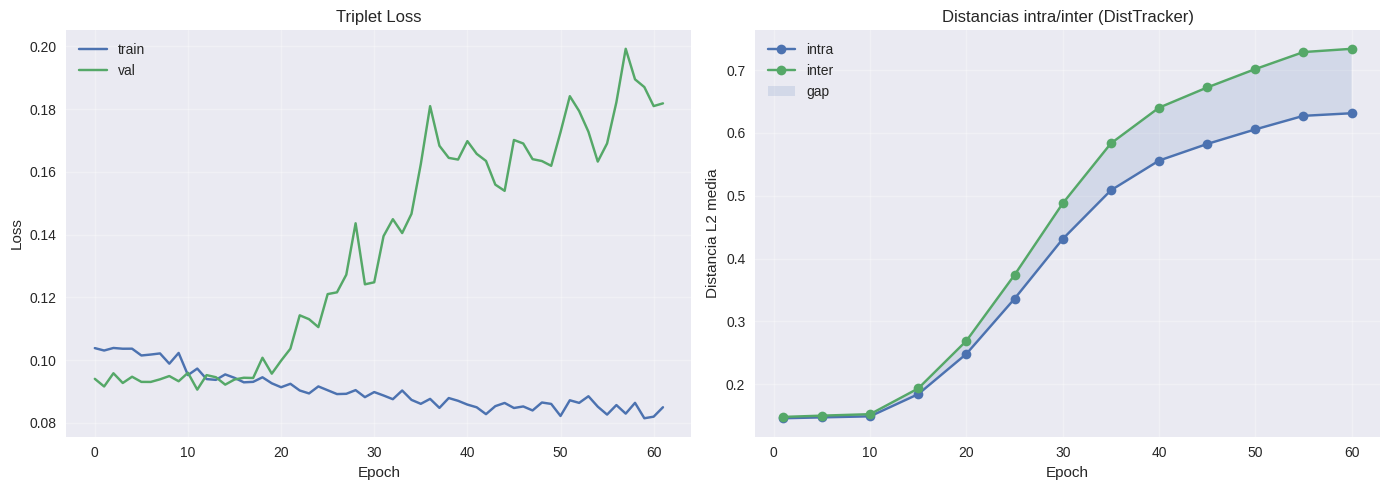

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history.get("loss", []), label="train")
axes[0].plot(history.history.get("val_loss", []), label="val")
axes[0].set_title("Triplet Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distancias intra/inter
if distance_tracker.history["epoch"]:
    dt = distance_tracker.history
    axes[1].plot(dt["epoch"], dt["mean_intra"], label="intra", marker="o")
    axes[1].plot(dt["epoch"], dt["mean_inter"], label="inter", marker="o")
    axes[1].fill_between(dt["epoch"], dt["mean_intra"], dt["mean_inter"],
                         alpha=0.15, label="gap")
    axes[1].set_title("Distancias intra/inter (DistTracker)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Distancia L2 media")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8b. Evolución de distancias L2 intra/inter durante el entrenamiento

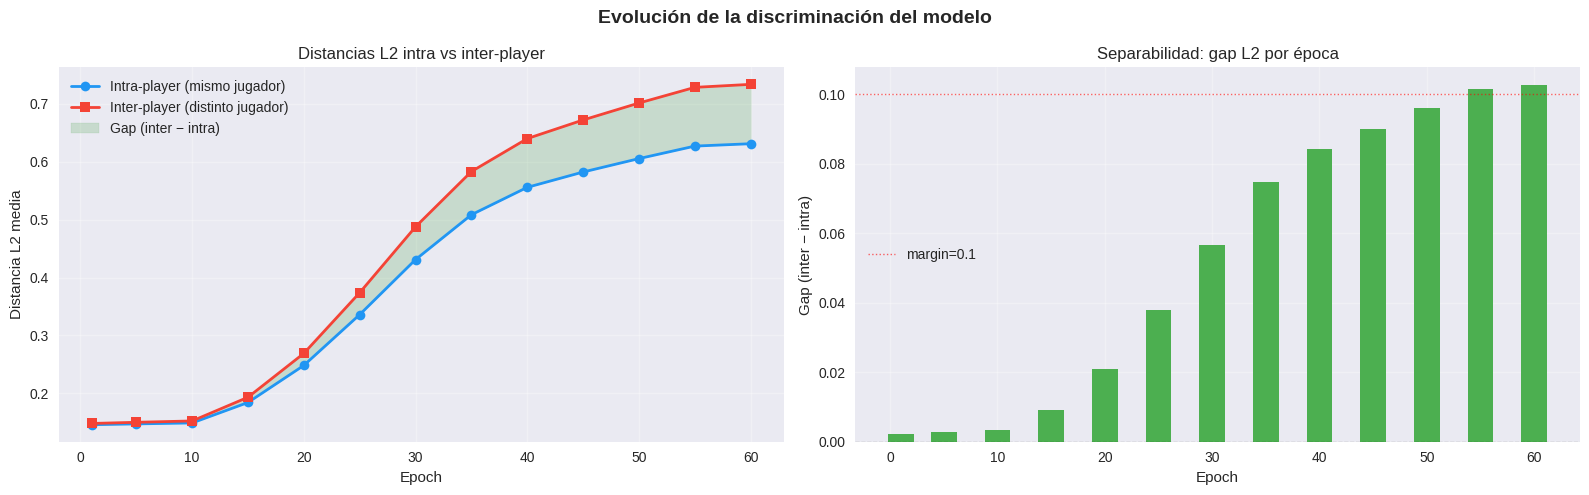

Epoch 1  → intra=0.1457  inter=0.1479  gap=0.0021
Último   → intra=0.6312  inter=0.7338  gap=0.1026
Mejora del gap: +0.1004 (+4707.2%)


In [35]:
dt = distance_tracker.history
epochs = dt["epoch"]
intra = dt["mean_intra"]
inter = dt["mean_inter"]
gap = dt["gap"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(epochs, intra, "o-", color="#2196F3", linewidth=2,
        label="Intra-player (mismo jugador)")
ax.plot(epochs, inter, "s-", color="#F44336", linewidth=2,
        label="Inter-player (distinto jugador)")
ax.fill_between(epochs, intra, inter, alpha=0.15, color="green",
                label="Gap (inter \u2212 intra)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Distancia L2 media")
ax.set_title("Distancias L2 intra vs inter-player")
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
bar_colors = ["#4CAF50" if g > 0 else "#F44336" for g in gap]
bar_w = max(1, epochs[-1] // len(epochs) * 0.6) if epochs else 1
ax2.bar(epochs, gap, color=bar_colors, width=bar_w)
ax2.axhline(y=0, color="k", linewidth=0.8, linestyle="--")
ax2.axhline(y=CONFIG["margin"], color="r", linewidth=1, linestyle=":",
            alpha=0.6, label=f"margin={CONFIG['margin']}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Gap (inter \u2212 intra)")
ax2.set_title("Separabilidad: gap L2 por \u00e9poca")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Evoluci\u00f3n de la discriminaci\u00f3n del modelo",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Epoch 1  \u2192 intra={intra[0]:.4f}  inter={inter[0]:.4f}  gap={gap[0]:.4f}")
print(f"\u00daltimo   \u2192 intra={intra[-1]:.4f}  inter={inter[-1]:.4f}  gap={gap[-1]:.4f}")
improvement = gap[-1] - gap[0]
pct = 100 * improvement / max(abs(gap[0]), 1e-8)
print(f"Mejora del gap: {improvement:+.4f} ({pct:+.1f}%)")

## 9. Validación de embeddings: reconstrucción de imágenes

**Prueba clave**: si el decoder puede reconstruir imágenes reconocibles desde el embedding,
entonces el embedding codifica información visual real y no es un vector de ruido.

2026-03-07 19:13:03,734 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  JMarcSennechael (ELO ~1174) | Game 0007 | MSE: 31893.8379


2026-03-07 19:13:04,352 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  Liquidador2013 (ELO ~945) | Game 0063 | MSE: 32814.9180


2026-03-07 19:13:04,972 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  KASIKE-ULTRA (ELO ~1763) | Game 0036 | MSE: 32518.7598


2026-03-07 19:13:05,585 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  JMarcSennechael (ELO ~1174) | Game 0140 | MSE: 32219.7676


2026-03-07 19:13:06,197 [WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


  JMarcSennechael (ELO ~1174) | Game 0109 | MSE: 32034.5332


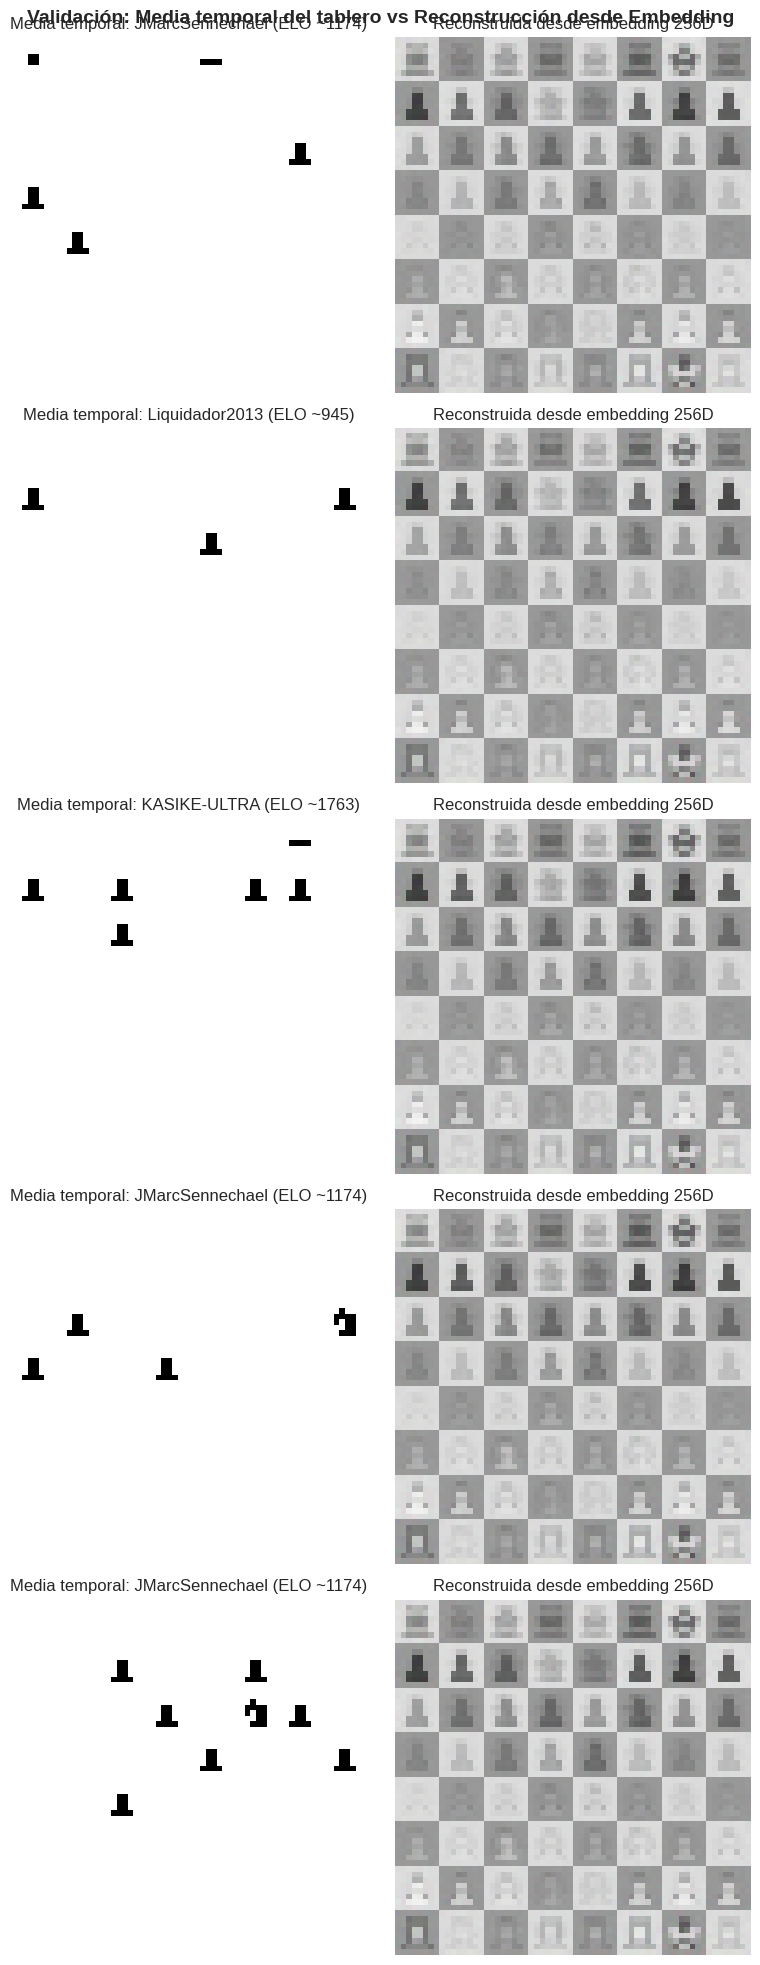

In [36]:
def validate_reconstruction(samples_by_player, embedding_model, decoder,
                             num_examples=5, seed=42):
    """Muestra la media temporal del tablero vs la imagen reconstruida desde el embedding."""
    rng = random.Random(seed)
    players = list(samples_by_player.keys())
    recon_h, recon_w = CONFIG["recon_size"]

    fig, axes = plt.subplots(num_examples, 2, figsize=(8, 4 * num_examples))
    if num_examples == 1:
        axes = axes.reshape(1, 2)

    for ex in range(num_examples):
        player = rng.choice(players)
        sample = rng.choice(samples_by_player[player])
        elo = PLAYER_ELO.get(player, "?")

        board_tensors, heat_tensors = [], []
        for bp, hp in zip(sample.board_paths, sample.heat_paths):
            b_img = tf.image.convert_image_dtype(
                tf.image.resize(
                    tf.io.decode_png(tf.io.read_file(bp), channels=3),
                    CONFIG["image_size"],
                ),
                tf.float32,
            )
            h_img = tf.image.convert_image_dtype(
                tf.image.resize(
                    tf.io.decode_png(tf.io.read_file(hp), channels=1),
                    CONFIG["image_size"],
                ),
                tf.float32,
            )
            board_tensors.append(b_img)
            heat_tensors.append(h_img)

        board_seq = tf.stack(board_tensors)[tf.newaxis, ...]
        heat_seq  = tf.stack(heat_tensors)[tf.newaxis, ...]
        emb   = embedding_model.predict(
            {"board_sequence": board_seq, "heat_sequence": heat_seq}, verbose=0
        )
        recon = decoder.predict(emb, verbose=0)[0]

        # Target: media temporal de todos los frames a 64x64
        frames_small = np.stack([
            tf.image.convert_image_dtype(
                tf.image.resize(
                    tf.io.decode_png(tf.io.read_file(bp), channels=3),
                    (recon_h, recon_w),
                ),
                tf.float32,
            ).numpy()
            for bp in sample.board_paths
        ])
        mean_frame = frames_small.mean(axis=0)

        axes[ex, 0].imshow(mean_frame)
        axes[ex, 0].set_title(f"Media temporal: {player} (ELO ~{elo})")
        axes[ex, 0].axis("off")

        axes[ex, 1].imshow(np.clip(recon, 0, 1))
        axes[ex, 1].set_title("Reconstruida desde embedding 256D")
        axes[ex, 1].axis("off")

        mse = float(np.mean((mean_frame - recon) ** 2))
        print(f"  {player} (ELO ~{elo}) | Game {sample.game_id} | MSE: {mse:.4f}")

    fig.suptitle("Validación: Media temporal del tablero vs Reconstrucción desde Embedding",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


validate_reconstruction(samples_by_player, embedding_model, decoder, num_examples=5)


## 10. Evaluación de embeddings: distancias intra/inter-player

75/75 [==============================] - 9s 114ms/step


,set,count,mean,median,min,max
0,intra-player,4350,0.158407,0.153747,0.062884,0.327204
1,inter-player,40500,0.166512,0.159819,0.066806,0.407907


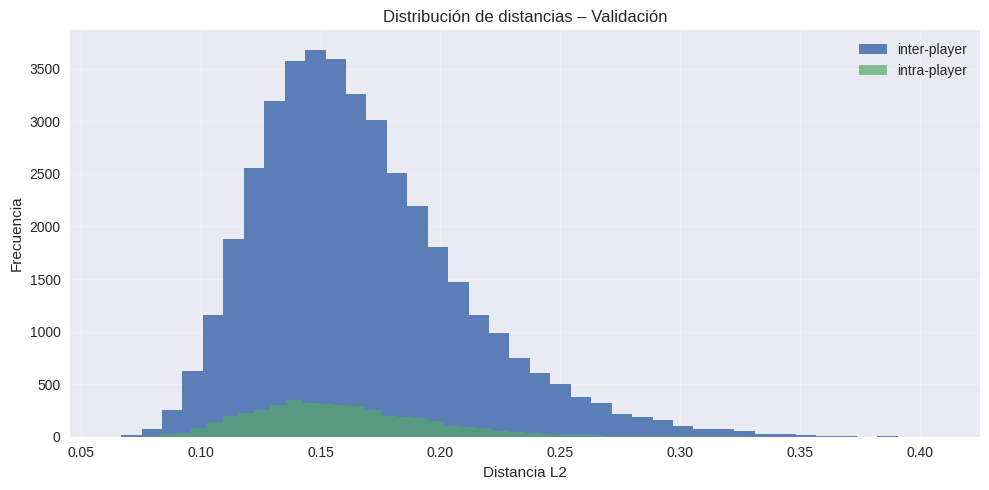

In [37]:
def build_embedding_dataset(samples: List[GameSample], batch_size: int):
    if not samples:
        raise RuntimeError("No hay muestras para evaluar.")

    board_paths = np.array([s.board_paths for s in samples])
    heat_paths = np.array([s.heat_paths for s in samples])
    metadata = [{"player": s.player, "game_id": s.game_id} for s in samples]

    ds = tf.data.Dataset.from_tensor_slices({"board": board_paths, "heat": heat_paths})
    ds = ds.map(
        lambda s: load_sample(s["board"], s["heat"]),
        num_parallel_calls=2,
    )
    ds = ds.batch(batch_size).prefetch(2)
    ds = ds.map(lambda board, heat: {"board_sequence": board, "heat_sequence": heat})
    return ds, metadata


val_embed_ds, val_metadata = build_embedding_dataset(VAL_SAMPLES, CONFIG["batch_size"])
val_embeddings = embedding_model.predict(val_embed_ds, verbose=1)

positive_distances, negative_distances = [], []
for i in range(len(val_embeddings)):
    for j in range(i + 1, len(val_embeddings)):
        dist = float(np.linalg.norm(val_embeddings[i] - val_embeddings[j]))
        if val_metadata[i]["player"] == val_metadata[j]["player"]:
            positive_distances.append(dist)
        else:
            negative_distances.append(dist)


def summarize_distances(name, values):
    if not values:
        return {"set": name, "count": 0, "mean": None}
    return {
        "set": name,
        "count": len(values),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


distance_summary = pd.DataFrame([
    summarize_distances("intra-player", positive_distances),
    summarize_distances("inter-player", negative_distances),
])
display(distance_summary)

plt.figure(figsize=(10, 5))
plt.hist(negative_distances, bins=40, alpha=0.9, label="inter-player")
plt.hist(positive_distances, bins=40, alpha=0.7, label="intra-player")
plt.xlabel("Distancia L2")
plt.ylabel("Frecuencia")
plt.title("Distribuci\u00f3n de distancias \u2013 Validaci\u00f3n")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Métricas avanzadas de calidad

In [38]:
print("AN\u00c1LISIS DE SEPARABILIDAD DEL MODELO\n")
print("=" * 80)

mean_intra = np.mean(positive_distances)
mean_inter = np.mean(negative_distances)

# 1. Separation Ratio
separation_ratio = mean_intra / mean_inter if mean_inter > 0 else float("inf")
print(f"\n1  SEPARATION RATIO: {separation_ratio:.4f}")
print(f"   mean(intra) / mean(inter) = {mean_intra:.6f} / {mean_inter:.6f}")
if separation_ratio < 0.5:
    print("      EXCELENTE: intra < 50% de inter")
elif separation_ratio < 0.7:
    print("       BUENO: separaci\u00f3n clara")
elif separation_ratio < 0.9:
    print("      REGULAR: separaci\u00f3n d\u00e9bil")
else:
    print("      MALO: sin separaci\u00f3n real")

# 2. Overlap
max_intra = np.max(positive_distances) if positive_distances else 0
min_inter = np.min(negative_distances) if negative_distances else 0
overlap_pct = (
    100 * np.sum(np.array(positive_distances) > np.median(negative_distances))
    / max(len(positive_distances), 1)
)
print(f"\n2  SOLAPAMIENTO: {overlap_pct:.1f}%")
print(f"   Max intra: {max_intra:.6f} | Min inter: {min_inter:.6f}")

# 3. Margen efectivo
effective_margin = mean_inter - mean_intra
print(f"\n3  MARGEN EFECTIVO: {effective_margin:.6f}")
print(f"   Margen configurado: {CONFIG['margin']}")
print("\n" + "=" * 80)

ANÁLISIS DE SEPARABILIDAD DEL MODELO


1  SEPARATION RATIO: 0.9513
   mean(intra) / mean(inter) = 0.158407 / 0.166512
      MALO: sin separación real

2  SOLAPAMIENTO: 43.4%
   Max intra: 0.327204 | Min inter: 0.066806

3  MARGEN EFECTIVO: 0.008105
   Margen configurado: 0.1



## 12. Verificación de embeddings: determinismo + centroides


Ejemplo 1: JMarcSennechael (ELO ~1174) | Partida 0007
  Shape: (256,)
  Norma L2: 1.0000
  Rango: [-0.0730, 0.2587]
  Determinismo (diff 2 pasadas): 0.00e+00 ✅ OK


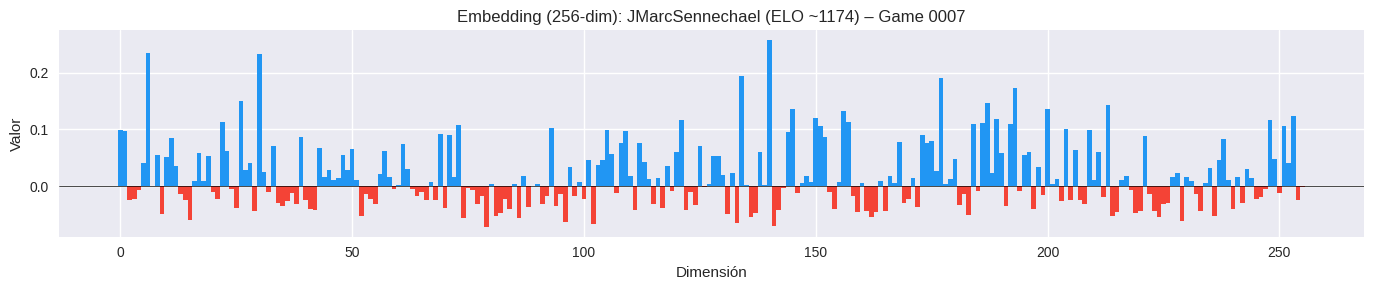


Ejemplo 2: Liquidador2013 (ELO ~945) | Partida 0063
  Shape: (256,)
  Norma L2: 1.0000
  Rango: [-0.0693, 0.2663]
  Determinismo (diff 2 pasadas): 0.00e+00 ✅ OK


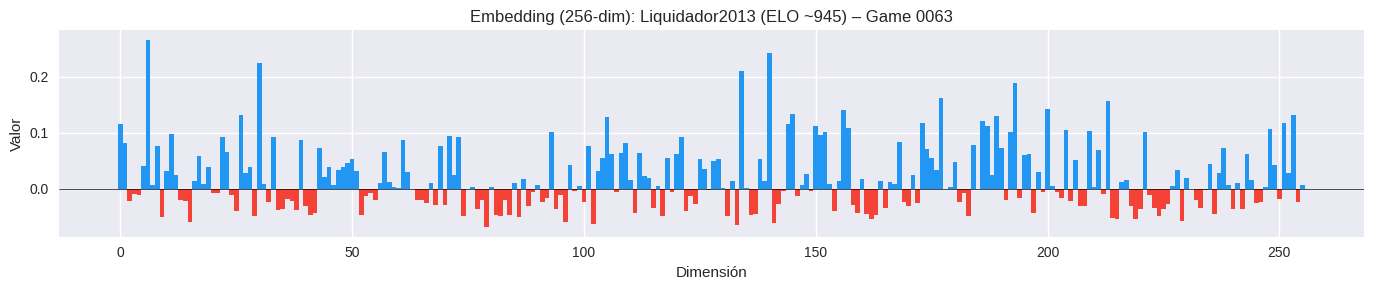


Ejemplo 3: KASIKE-ULTRA (ELO ~1763) | Partida 0036
  Shape: (256,)
  Norma L2: 1.0000
  Rango: [-0.0719, 0.2485]
  Determinismo (diff 2 pasadas): 0.00e+00 ✅ OK


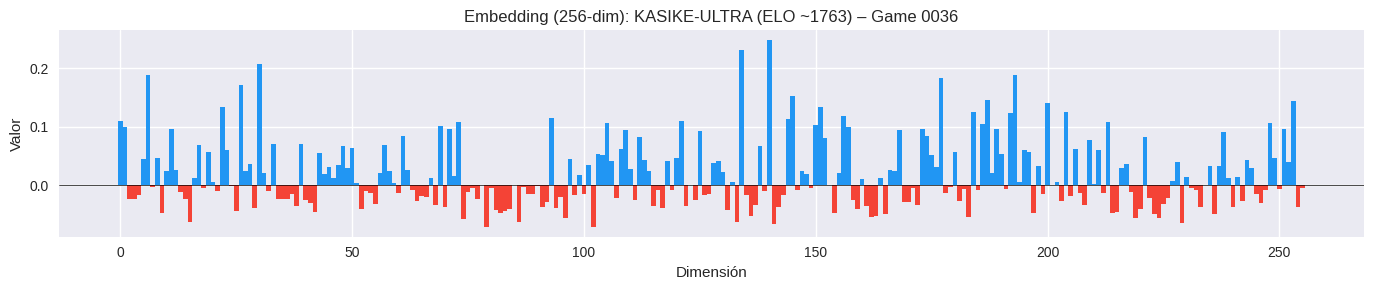


DISTANCIAS ENTRE CENTROIDES DE JUGADORES


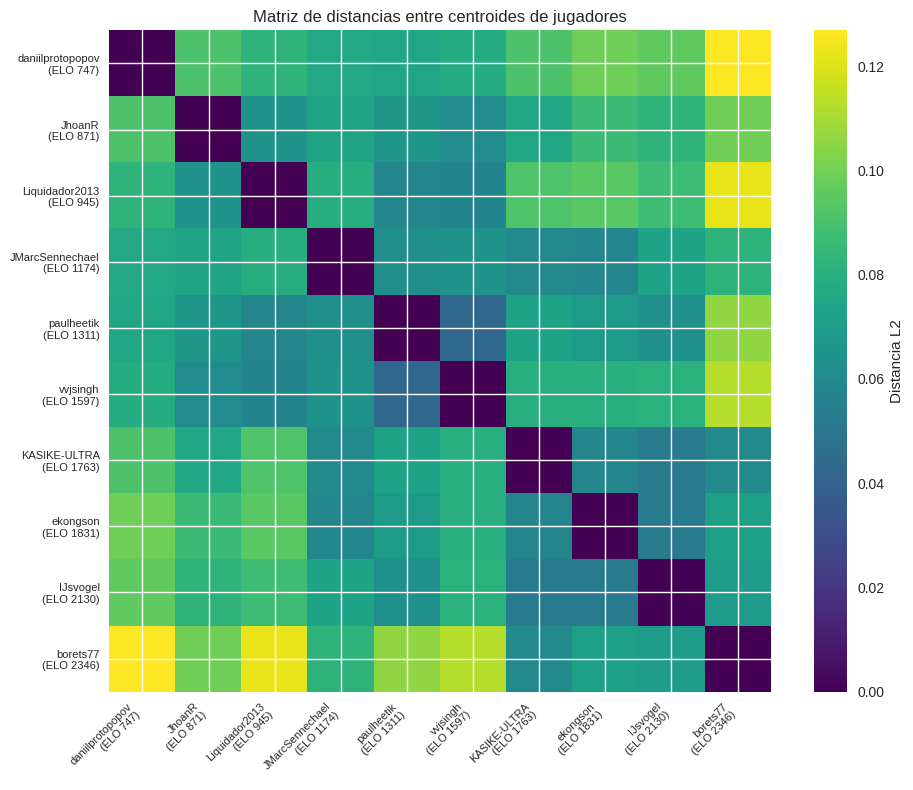

In [39]:
def verify_embedding_pipeline(samples_by_player, embedding_model, num_examples=3, seed=42):
    """Verificaci\u00f3n visual + determinismo de embeddings."""
    rng = random.Random(seed)
    players = list(samples_by_player.keys())

    for ex in range(num_examples):
        player = rng.choice(players)
        sample = rng.choice(samples_by_player[player])
        elo = PLAYER_ELO.get(player, "?")

        print(f"\n{'=' * 70}")
        print(f"Ejemplo {ex+1}: {player} (ELO ~{elo}) | Partida {sample.game_id}")
        print(f"{'=' * 70}")

        board_tensors, heat_tensors = [], []
        for bp, hp in zip(sample.board_paths, sample.heat_paths):
            b_img = tf.image.convert_image_dtype(
                tf.image.resize(
                    tf.io.decode_png(tf.io.read_file(bp), channels=3),
                    CONFIG["image_size"],
                ),
                tf.float32,
            )
            h_img = tf.image.convert_image_dtype(
                tf.image.resize(
                    tf.io.decode_png(tf.io.read_file(hp), channels=1),
                    CONFIG["image_size"],
                ),
                tf.float32,
            )
            board_tensors.append(b_img)
            heat_tensors.append(h_img)

        board_seq = tf.stack(board_tensors)[tf.newaxis, ...]
        heat_seq = tf.stack(heat_tensors)[tf.newaxis, ...]

        emb1 = embedding_model.predict(
            {"board_sequence": board_seq, "heat_sequence": heat_seq}, verbose=0
        )[0]
        print(f"  Shape: {emb1.shape}")
        print(f"  Norma L2: {np.linalg.norm(emb1):.4f}")
        print(f"  Rango: [{emb1.min():.4f}, {emb1.max():.4f}]")

        emb2 = embedding_model.predict(
            {"board_sequence": board_seq, "heat_sequence": heat_seq}, verbose=0
        )[0]
        diff = np.linalg.norm(emb1 - emb2)
        status = "\u2705 OK" if diff < 1e-5 else "\u274c INCONSISTENTE"
        print(f"  Determinismo (diff 2 pasadas): {diff:.2e} {status}")

        fig, ax = plt.subplots(figsize=(14, 3))
        colors = ["#2196F3" if v >= 0 else "#F44336" for v in emb1]
        ax.bar(range(len(emb1)), emb1, color=colors, width=1.0)
        ax.set_title(f"Embedding (256-dim): {player} (ELO ~{elo}) \u2013 Game {sample.game_id}")
        ax.set_xlabel("Dimensi\u00f3n")
        ax.set_ylabel("Valor")
        ax.axhline(y=0, color="k", linewidth=0.5)
        plt.tight_layout()
        plt.show()

    # Matriz de distancias entre centroides
    print(f"\n{'=' * 70}")
    print("DISTANCIAS ENTRE CENTROIDES DE JUGADORES")
    print(f"{'=' * 70}")

    centroids = {}
    for player, samples in samples_by_player.items():
        embs = []
        for s in samples[:5]:
            bt, ht = [], []
            for bp, hp in zip(s.board_paths, s.heat_paths):
                b_t = tf.image.convert_image_dtype(
                    tf.image.resize(
                        tf.io.decode_png(tf.io.read_file(bp), channels=3),
                        CONFIG["image_size"],
                    ),
                    tf.float32,
                )
                h_t = tf.image.convert_image_dtype(
                    tf.image.resize(
                        tf.io.decode_png(tf.io.read_file(hp), channels=1),
                        CONFIG["image_size"],
                    ),
                    tf.float32,
                )
                bt.append(b_t)
                ht.append(h_t)
            bs = tf.stack(bt)[tf.newaxis, ...]
            hs = tf.stack(ht)[tf.newaxis, ...]
            e = embedding_model.predict(
                {"board_sequence": bs, "heat_sequence": hs}, verbose=0
            )[0]
            embs.append(e)
        centroids[player] = np.mean(embs, axis=0)

    players_sorted = sorted(centroids.keys(), key=lambda p: PLAYER_ELO.get(p, 0))
    n = len(players_sorted)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_matrix[i, j] = np.linalg.norm(
                centroids[players_sorted[i]] - centroids[players_sorted[j]]
            )

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(dist_matrix, cmap="viridis")
    labels = [f"{p}\n(ELO {PLAYER_ELO.get(p, '?')})" for p in players_sorted]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=8)
    plt.colorbar(im, label="Distancia L2")
    plt.title("Matriz de distancias entre centroides de jugadores")
    plt.tight_layout()
    plt.show()


verify_embedding_pipeline(samples_by_player, embedding_model, num_examples=3)

## 13. Exportación de embeddings y centroides

In [40]:
def export_embedding_cache(samples: List[GameSample], model: Model, output_dir: Path):
    output_dir = Path(output_dir) / CONFIG["event_name"]
    output_dir.mkdir(parents=True, exist_ok=True)

    ds, metadata = build_embedding_dataset(samples, CONFIG["batch_size"])
    embeddings = model.predict(ds, verbose=1)

    centroids: Dict[str, List[np.ndarray]] = {}
    for emb, meta in zip(embeddings, metadata):
        player_dir = output_dir / meta["player"]
        player_dir.mkdir(parents=True, exist_ok=True)
        np.save(player_dir / f"{meta['game_id']}.npy", emb.astype(np.float32))
        centroids.setdefault(meta["player"], []).append(emb)

    centroid_payload = {}
    for player, vectors in centroids.items():
        stacked = np.vstack(vectors)
        centroid = np.mean(stacked, axis=0).astype(np.float32)
        centroid_path = output_dir / player / "centroid.npy"
        np.save(centroid_path, centroid)
        centroid_payload[player] = {
            "samples": len(vectors),
            "elo": PLAYER_ELO.get(player, None),
            "centroid_path": str(centroid_path),
        }

    manifest = {
        "event": CONFIG["event_name"],
        "players": len(centroid_payload),
        "games_per_player": CONFIG["games_per_player"],
        "updated_at": datetime.utcnow().isoformat() + "Z",
        "config": {
            k: str(v) if isinstance(v, Path) else v
            for k, v in CONFIG.items()
            if k not in ("embedding_cache_dir",)
        },
        "vectors": centroid_payload,
    }
    manifest_path = output_dir / "manifest.json"
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    print(f"Embeddings exportados a {output_dir}")
    print(f"Manifest: {manifest_path}")
    return manifest_path


manifest_path = export_embedding_cache(
    TRAIN_SAMPLES + VAL_SAMPLES,
    embedding_model,
    CONFIG["embedding_cache_dir"],
)
print(f"\nManifest guardado en: {manifest_path}")

375/375 [==============================] - 43s 115ms/step
Embeddings exportados a /workspace/code/labs/dataset/embedding_103/compressed_103
Manifest: /workspace/code/labs/dataset/embedding_103/compressed_103/manifest.json

Manifest guardado en: /workspace/code/labs/dataset/embedding_103/compressed_103/manifest.json


/tmp/ipykernel_143/2103324415.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "updated_at": datetime.utcnow().isoformat() + "Z",


In [41]:
# ── Exportar pesos del modelo para poder saltar el entrenamiento ──
WEIGHTS_DIR = OUTPUT_BASE / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

embedding_model.save_weights(str(WEIGHTS_DIR / "embedding_model.h5"))
decoder.save_weights(str(WEIGHTS_DIR / "decoder.h5"))
siamese_model.siamese_network.save_weights(str(WEIGHTS_DIR / "siamese_network.h5"))

print(f"Pesos guardados en: {WEIGHTS_DIR}")
for wf in sorted(WEIGHTS_DIR.glob("*.h5")):
    print(f"  {wf.name}  ({wf.stat().st_size / 1024:.0f} KB)")

Pesos guardados en: /workspace/code/labs/notebooks/output/events/compressed_103/weights
  decoder.h5  (4372 KB)
  embedding_model.h5  (102041 KB)
  siamese_network.h5  (102034 KB)


## 14. Validación con partidas NO vistas (True Hold-Out Test)

Se cargan partidas **completamente nuevas** (no usadas en entrenamiento ni validación)
para cada jugador, se generan sus embeddings y se comparan contra los centroides
calculados **únicamente** con datos de entrenamiento.

> Esto da la **medida real de rendimiento** del modelo.

In [42]:
TEST_GAMES_PER_PLAYER = 30

TEST_OUTPUT_BASE = OUTPUT_BASE / "test_holdout"
TEST_BOARD_DIR   = TEST_OUTPUT_BASE / "board_images"
TEST_HEAT_DIR    = TEST_OUTPUT_BASE / "heatmap_images"
TEST_PGN_DIR     = TEST_OUTPUT_BASE / "pgn_decompressed"


def decompress_test_pgn(player_name, zst_path, output_dir, skip_games, max_games):
    """Descomprime partidas de test: salta las primeras *skip_games* y toma *max_games*."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{player_name}.pgn"

    dctx = zstd.ZstdDecompressor()
    with open(zst_path, "rb") as f:
        reader = dctx.stream_reader(f)
        full_text = reader.read().decode("utf-8", errors="replace")

    # Separar partidas por cabecera [Event ...]
    games = []
    current_lines = []
    for line in full_text.split("\n"):
        if line.startswith("[Event ") and current_lines:
            games.append("\n".join(current_lines))
            current_lines = []
        current_lines.append(line)
    if current_lines:
        games.append("\n".join(current_lines))

    test_games = games[skip_games : skip_games + max_games]

    with open(output_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(test_games))

    return output_path, len(test_games)


# Descomprimir partidas de test para cada jugador
test_decompression = []
for _, row in selected_players_df.iterrows():
    zst = find_zst_path(row["player"])
    if zst is None:
        print(f"  SKIP {row['player']}: .zst no encontrado")
        continue
    pgn_path, n_games = decompress_test_pgn(
        row["player"], zst, TEST_PGN_DIR,
        skip_games=CONFIG["games_per_player"],
        max_games=TEST_GAMES_PER_PLAYER,
    )
    test_decompression.append({
        "player": row["player"], "pgn_path": str(pgn_path), "games": n_games,
    })
    print(f"  {row['player']}: {n_games} partidas de test")

test_decompression_df = pd.DataFrame(test_decompression)
print(f"\nTotal partidas de test descomprimidas: {test_decompression_df['games'].sum()}")

  daniilprotopopov: 30 partidas de test
  JhoanR: 30 partidas de test
  Liquidador2013: 30 partidas de test
  JMarcSennechael: 30 partidas de test
  paulheetik: 30 partidas de test
  vvjsingh: 30 partidas de test
  KASIKE-ULTRA: 30 partidas de test
  ekongson: 30 partidas de test
  IJsvogel: 30 partidas de test
  borets77: 30 partidas de test

Total partidas de test descomprimidas: 300


In [43]:
# Generar imágenes de tablero + heatmap para las partidas de test
for result in test_decompression:
    player   = result["player"]
    pgn_path = Path(result["pgn_path"])

    player_board_dir = TEST_BOARD_DIR / player
    player_heat_dir  = TEST_HEAT_DIR  / player

    stats = generate_per_move_images(
        pgn_path, player_board_dir, player_heat_dir,
        start_hm=START_HM, end_hm=END_HM, verbose=False,
    )
    print(f"  {player}: {stats}")

print("\nImágenes de test generadas.")

  daniilprotopopov: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  JhoanR: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  Liquidador2013: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  JMarcSennechael: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  paulheetik: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  vvjsingh: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  KASIKE-ULTRA: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  ekongson: {'games_processed': 30, 'games_skipped': 0, 'boards_created': 900, 'heatmaps_created': 900, 'errors': 0}
  IJsvogel: {'games_processed': 30, 'ga

In [44]:
# Descubrir muestras de test
test_samples_by_player, test_stats = discover_game_samples(
    TEST_BOARD_DIR, TEST_HEAT_DIR, BLOCK_LABELS,
    min_samples=1,
)
display(test_stats)

test_flat = [s for ss in test_samples_by_player.values() for s in ss]
print(f"\nPartidas de test con imágenes completas: {len(test_flat)}")
print(f"Jugadores con partidas de test: {len(test_samples_by_player)}")

,player,games
0,IJsvogel,30
1,JMarcSennechael,30
2,JhoanR,30
3,KASIKE-ULTRA,30
4,Liquidador2013,30
5,borets77,30
6,daniilprotopopov,30
7,ekongson,30
8,paulheetik,30
9,vvjsingh,30



Partidas de test con imágenes completas: 300
Jugadores con partidas de test: 10


### 14a. Centroides de entrenamiento y clasificación por centroide más cercano

Se calculan los centroides usando **solo** los datos de entrenamiento (`train_by_player`).
Después se compara cada partida de test contra todos los centroides.

In [45]:
# ── Centroides solo con datos de ENTRENAMIENTO ──
train_ds, train_meta = build_embedding_dataset(TRAIN_SAMPLES, CONFIG["batch_size"])
train_embeddings = embedding_model.predict(train_ds, verbose=1)

train_centroids = {}
for emb, meta in zip(train_embeddings, train_meta):
    train_centroids.setdefault(meta["player"], []).append(emb)

for player in train_centroids:
    train_centroids[player] = np.mean(np.vstack(train_centroids[player]), axis=0)

print(f"Centroides calculados para {len(train_centroids)} jugadores (solo TRAIN)")

# ── Embeddings de las partidas de test ──
test_ds, test_meta = build_embedding_dataset(test_flat, CONFIG["batch_size"])
test_embeddings = embedding_model.predict(test_ds, verbose=1)

# ── Clasificar cada partida de test por centroide más cercano ──
centroid_players = sorted(train_centroids.keys())
centroid_matrix  = np.vstack([train_centroids[p] for p in centroid_players])

y_true, y_pred = [], []
dist_to_own, dist_to_nearest_other = [], []

for emb, meta in zip(test_embeddings, test_meta):
    true_player = meta["player"]
    dists = np.linalg.norm(centroid_matrix - emb, axis=1)
    pred_idx = int(np.argmin(dists))
    pred_player = centroid_players[pred_idx]

    y_true.append(true_player)
    y_pred.append(pred_player)

    if true_player in train_centroids:
        own_d = float(np.linalg.norm(emb - train_centroids[true_player]))
        dist_to_own.append(own_d)
        other_ds = [float(np.linalg.norm(emb - train_centroids[p]))
                    for p in centroid_players if p != true_player]
        if other_ds:
            dist_to_nearest_other.append(min(other_ds))

accuracy = np.mean([t == p for t, p in zip(y_true, y_pred)])
print(f"\n{'='*60}")
print(f"  ACCURACY (centroide más cercano): {accuracy:.2%}")
print(f"  Partidas de test evaluadas:       {len(y_true)}")
print(f"{'='*60}")

300/300 [==============================] - 34s 112ms/step
Centroides calculados para 10 jugadores (solo TRAIN)
75/75 [==============================] - 9s 115ms/step

  ACCURACY (centroide más cercano): 25.00%
  Partidas de test evaluadas:       300


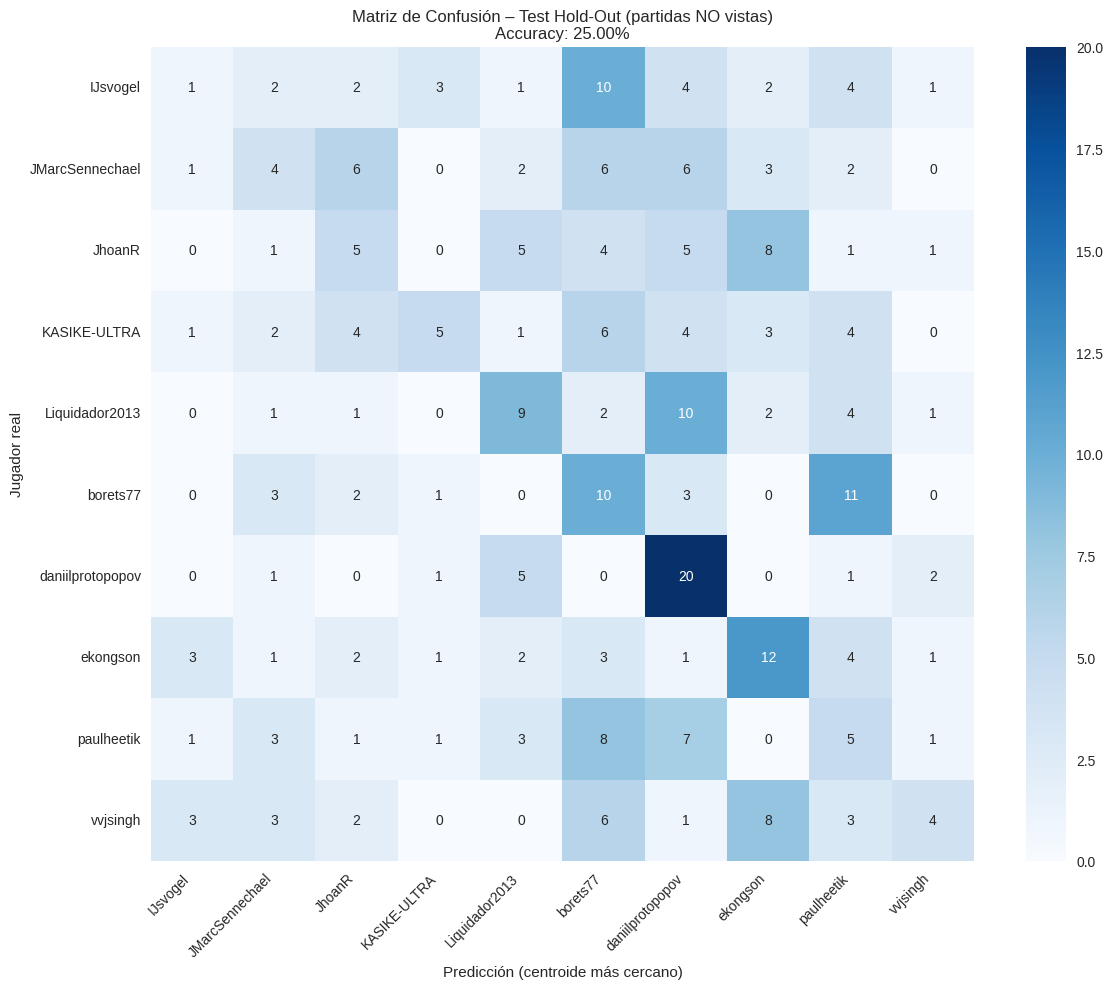


Reporte de clasificación:

                  precision    recall  f1-score   support

        IJsvogel       0.10      0.03      0.05        30
 JMarcSennechael       0.19      0.13      0.16        30
          JhoanR       0.20      0.17      0.18        30
    KASIKE-ULTRA       0.42      0.17      0.24        30
  Liquidador2013       0.32      0.30      0.31        30
        borets77       0.18      0.33      0.24        30
daniilprotopopov       0.33      0.67      0.44        30
        ekongson       0.32      0.40      0.35        30
      paulheetik       0.13      0.17      0.14        30
        vvjsingh       0.36      0.13      0.20        30

        accuracy                           0.25       300
       macro avg       0.25      0.25      0.23       300
    weighted avg       0.25      0.25      0.23       300



In [46]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

labels = sorted(set(y_true + y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicción (centroide más cercano)")
ax.set_ylabel("Jugador real")
ax.set_title(f"Matriz de Confusión – Test Hold-Out (partidas NO vistas)\nAccuracy: {accuracy:.2%}")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

ANÁLISIS DE DISTANCIAS – TEST HOLD-OUT (partidas NO vistas)

  Dist. media a centroide propio:              0.112581
  Dist. media a centroide ajeno más cercano:   0.101375
  Ratio intra/inter:                           1.1105
  Margen efectivo:                             -0.011206


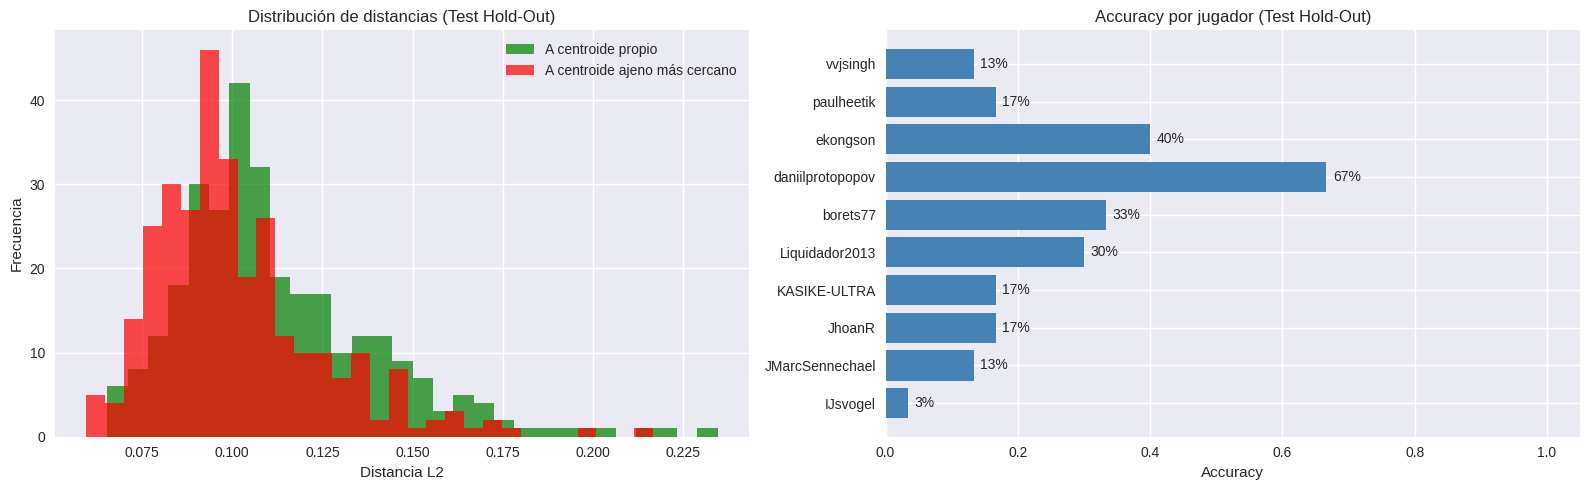

In [47]:
print("ANÁLISIS DE DISTANCIAS – TEST HOLD-OUT (partidas NO vistas)\n")
print("=" * 60)

mean_own   = np.mean(dist_to_own)
mean_other = np.mean(dist_to_nearest_other)
ratio      = mean_own / mean_other if mean_other > 0 else float("inf")
margin     = mean_other - mean_own

print(f"  Dist. media a centroide propio:              {mean_own:.6f}")
print(f"  Dist. media a centroide ajeno más cercano:   {mean_other:.6f}")
print(f"  Ratio intra/inter:                           {ratio:.4f}")
print(f"  Margen efectivo:                             {margin:.6f}")
print("=" * 60)

# ── Histograma de distancias ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(dist_to_own, bins=30, alpha=0.7,
             label="A centroide propio", color="green")
axes[0].hist(dist_to_nearest_other, bins=30, alpha=0.7,
             label="A centroide ajeno más cercano", color="red")
axes[0].set_xlabel("Distancia L2")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de distancias (Test Hold-Out)")
axes[0].legend()

# ── Accuracy por jugador ──
player_correct, player_total = {}, {}
for t, p in zip(y_true, y_pred):
    player_total[t] = player_total.get(t, 0) + 1
    if t == p:
        player_correct[t] = player_correct.get(t, 0) + 1

players_sorted = sorted(player_total.keys())
accs = [player_correct.get(p, 0) / player_total[p] for p in players_sorted]

axes[1].barh(players_sorted, accs, color="steelblue")
axes[1].set_xlabel("Accuracy")
axes[1].set_title("Accuracy por jugador (Test Hold-Out)")
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(accs):
    axes[1].text(v + 0.01, i, f"{v:.0%}", va="center")

plt.tight_layout()
plt.show()